In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import Normalize
from PIL import Image

import numpy as np

def compute_gradient(u, h=1.0):
    """计算二维数组的梯度（中心差分，边界用单向差分）"""
    grad_x = np.zeros_like(u)
    grad_y = np.zeros_like(u)
    
    # x方向梯度
    grad_x[:, 1:-1] = (u[:, 2:] - u[:, :-2]) / (2 * h)  # 中心差分
    grad_x[:, 0] = (u[:, 1] - u[:, 0]) / h               # 左边界向前差分
    grad_x[:, -1] = (u[:, -1] - u[:, -2]) / h            # 右边界向后差分
    
    # y方向梯度
    grad_y[1:-1, :] = (u[2:, :] - u[:-2, :]) / (2 * h)  # 中心差分
    grad_y[0, :] = (u[1, :] - u[0, :]) / h              # 上边界向前差分
    grad_y[-1, :] = (u[-1, :] - u[-2, :]) / h           # 下边界向后差分
    
    return grad_x, grad_y

def compute_hessian(u, h=1.0):
    """计算二维数组的Hessian矩阵（二阶导数）"""
    # 二阶偏导数
    u_xx = (u[:, 2:] - 2 * u[:, 1:-1] + u[:, :-2]) / (h**2)  # ∂²u/∂x²
    u_yy = (u[2:, :] - 2 * u[1:-1, :] + u[:-2, :]) / (h**2)  # ∂²u/∂y²
    u_xy = (u[2:, 2:] - u[2:, :-2] - u[:-2, 2:] + u[:-2, :-2]) / (4 * h**2)  # ∂²u/∂x∂y
    
    # 填充边界（边界二阶导数无法计算，设为NaN）
    hess_xx = np.full_like(u, np.nan)
    hess_yy = np.full_like(u, np.nan)
    hess_xy = np.full_like(u, np.nan)
    
    hess_xx[:, 1:-1] = u_xx
    hess_yy[1:-1, :] = u_yy
    hess_xy[1:-1, 1:-1] = u_xy
    
    return hess_xx, hess_yy, hess_xy

def periodic_boundary_error(u):
    """计算二维信号边界周期性误差（0阶、1阶、2阶导数）"""
    N = u.shape[0]
    assert u.shape == (N, N), "输入必须是N×N的二维数组"
    
    # 0阶误差：直接比较边界值
    top = u[0, :]    # 上边界
    bottom = u[-1, :] # 下边界
    left = u[:, 0]    # 左边界
    right = u[:, -1]  # 右边界
    
    error_0th = (np.mean(np.abs(top - bottom)) + np.mean(np.abs(left - right))) / 2
    
    # 1阶误差：比较梯度
    grad_x, grad_y = compute_gradient(u)
    
    # x方向梯度在左右边界的差异
    grad_x_left = grad_x[:, 0]
    grad_x_right = grad_x[:, -1]
    error_grad_x = np.mean(np.abs(grad_x_left - grad_x_right))
    
    # y方向梯度在上下边界的差异
    grad_y_top = grad_y[0, :]
    grad_y_bottom = grad_y[-1, :]
    error_grad_y = np.mean(np.abs(grad_y_top - grad_y_bottom))
    
    error_1st = (error_grad_x + error_grad_y) / 2
    
    # 2阶误差：比较Hessian（仅内部点）
    hess_xx, hess_yy, hess_xy = compute_hessian(u)
    
    # 提取有效Hessian边界（忽略NaN）
    valid_hess_xx = hess_xx[1:-1, 1:-1]
    valid_hess_yy = hess_yy[1:-1, 1:-1]
    valid_hess_xy = hess_xy[1:-1, 1:-1]
    
    # 比较上下边界的Hessian（均值）
    hess_xx_top = hess_xx[1, 1:-1]    # 上边界内部
    hess_xx_bottom = hess_xx[-2, 1:-1] # 下边界内部
    error_hess_xx = np.mean(np.abs(hess_xx_top - hess_xx_bottom))
    
    hess_yy_left = hess_yy[1:-1, 1]    # 左边界内部
    hess_yy_right = hess_yy[1:-1, -2]  # 右边界内部
    error_hess_yy = np.mean(np.abs(hess_yy_left - hess_yy_right))
    
    error_2nd = (error_hess_xx + error_hess_yy) / 2
    
    # 转换为百分比误差（相对于信号幅值）
    max_abs_u = np.max(np.abs(u))
    error_0th_pct = 100 * error_0th / max_abs_u if max_abs_u != 0 else 0
    error_1st_pct = 100 * error_1st / max_abs_u if max_abs_u != 0 else 0
    error_2nd_pct = 100 * error_2nd / max_abs_u if max_abs_u != 0 else 0
    
    return {
        "0th_order_error (%)": error_0th_pct,
        "1st_order_error (%)": error_1st_pct,
        "2nd_order_error (%)": error_2nd_pct
    }

def create_attack_visualization(records, output_path="attack_progress.gif", fps=2, dpi=100, metadata=None):
    os.makedirs('temp_frames', exist_ok=True)
    frame_files = []
    
    # Prepare loss data
    steps = [r['step'] for r in records]
    losses = [r['loss'] for r in records]
    
    # Calculate global min/max for consistent color scaling
    vmax_diff = max(np.max(np.abs(r['output'] - r['truth'])) for r in records)
    vmax_grad = max(np.max(np.abs(r['gradient'])) for r in records)
    
    # Create parameter string for title
    param_str = ""
    if metadata:
        param_str = " | " + ", ".join([f"{k}={v}" for k,v in metadata.items()])
    
    for i, record in enumerate(records):
        fig, axs = plt.subplots(2, 3, figsize=(18, 12))
        
        # Main title with parameters
        main_title = f'PGD Attack Progress - Step {i}{param_str}'
        fig.suptitle(main_title, fontsize=16)
        
        # Get data for current step
        x0 = record['x0']
        grad = record['gradient']
        output = record['output']
        truth = record['truth']
        diff = output - truth
        mean_abs_diff = np.mean(np.abs(diff))
        
        # Calculate periodicity metrics using the pre-defined function
        x0_metrics = periodic_boundary_error(x0)
        grad_metrics = periodic_boundary_error(grad)
        
        # Format metrics strings with all three orders
        x0_metric_str = (f"Periodicity:\n"
                        f"0th={x0_metrics['0th_order_error (%)']:.1f}% | "
                        f"1st={x0_metrics['1st_order_error (%)']:.1f}% | "
                        f"2nd={x0_metrics['2nd_order_error (%)']:.1f}%")
        
        grad_metric_str = (f"Periodicity:\n"
                         f"0th={grad_metrics['0th_order_error (%)']:.1f}% | "
                         f"1st={grad_metrics['1st_order_error (%)']:.1f}% | "
                         f"2nd={grad_metrics['2nd_order_error (%)']:.1f}%")
        
        # Plot 1: x0 (input) with periodicity metrics
        im1 = axs[0,0].imshow(x0, cmap='viridis')
        axs[0,0].set_title(f'Adversarial Input (x0)\n{x0_metric_str}', fontsize=10)
        fig.colorbar(im1, ax=axs[0,0])
        
        # Plot 2: Gradient with periodicity metrics
        im2 = axs[0,1].imshow(grad, cmap='viridis', vmin=-vmax_grad, vmax=vmax_grad)
        axs[0,1].set_title(f'Attack Gradient\n{grad_metric_str}', fontsize=10)
        fig.colorbar(im2, ax=axs[0,1])
        
        # Plot 3: Model Output
        im3 = axs[0,2].imshow(output, cmap='viridis')
        axs[0,2].set_title('Model Output')
        fig.colorbar(im3, ax=axs[0,2])
        
        # Plot 4: Ground Truth
        im4 = axs[1,0].imshow(truth, cmap='viridis')
        axs[1,0].set_title('Ground Truth')
        fig.colorbar(im4, ax=axs[1,0])
        
        # Plot 5: Difference (Output - Truth)
        im5 = axs[1,1].imshow(diff, cmap='coolwarm', 
                             norm=Normalize(vmin=-vmax_diff, vmax=vmax_diff))
        axs[1,1].set_title(f'Output-Truth\nMean Abs Diff: {mean_abs_diff:.4f}')
        fig.colorbar(im5, ax=axs[1,1])
        
        # Plot 6: Loss progression
        axs[1,2].plot(steps[:i+1], losses[:i+1], 'b-', marker='o')
        axs[1,2].set_title('Loss Progression')
        axs[1,2].set_xlabel('Attack Step')
        axs[1,2].set_ylabel('Loss')
        axs[1,2].grid(True)
        axs[1,2].set_xlim(-0.5, len(records)-0.5)
        axs[1,2].set_ylim(min(losses)*0.9, max(losses)*1.1)
        
        plt.tight_layout()
        
        # Save frame
        frame_file = f"temp_frames/frame_{i:04d}.png"
        plt.savefig(frame_file, dpi=dpi, bbox_inches='tight')
        frame_files.append(frame_file)
        plt.close()
    
    # Create GIF from frames
    images = [Image.open(f) for f in frame_files]
    images[0].save(output_path,
                  save_all=True,
                  append_images=images[1:],
                  duration=1000//fps,
                  loop=0)
    
    # Clean up temporary files
    for f in frame_files:
        os.remove(f)
    os.rmdir('temp_frames')
    
    print(f"GIF successfully saved to {output_path}")

def create_compact_attack_visualization(records, output_path="compact_attack_progress.gif", fps=2, dpi=100, metadata=None):
    os.makedirs('temp_frames', exist_ok=True)
    frame_files = []
    
    # Create parameter string for title
    param_str = ""
    if metadata:
        param_str = " | " + ", ".join([f"{k}={v}" for k,v in metadata.items()])
    
    for i, record in enumerate(records):
        fig, axs = plt.subplots(2, 2, figsize=(12, 12))
        
        # Main title with parameters
        main_title = f'Compact Attack Progress - Step {i}{param_str}'
        fig.suptitle(main_title, fontsize=16)
        
        # Get data for current step
        x0 = record['x0']
        grad = record['gradient']
        output = record['output']
        truth = record['truth']
        
        # Calculate periodicity metrics for all four arrays
        x0_metrics = periodic_boundary_error(x0)
        grad_metrics = periodic_boundary_error(grad)
        output_metrics = periodic_boundary_error(output)
        truth_metrics = periodic_boundary_error(truth)
        
        # Format metrics strings for all plots
        def format_metrics(metrics, name):
            return (f"{name}\nPeriodicity:\n"
                   f"0th={metrics['0th_order_error (%)']:.1f}% | "
                   f"1st={metrics['1st_order_error (%)']:.1f}% | "
                   f"2nd={metrics['2nd_order_error (%)']:.1f}%")
        
        # Create tiled versions of each array (4 repeats)
        def tile_array(arr):
            return np.tile(arr, (2, 2))
        
        # Plot 1: x0 (input)
        tiled_x0 = tile_array(x0)
        im1 = axs[0,0].imshow(tiled_x0, cmap='viridis')
        axs[0,0].set_title(format_metrics(x0_metrics, 'Adversarial Input (x0)'), fontsize=9)
        fig.colorbar(im1, ax=axs[0,0])
        
        # Plot 2: Gradient
        tiled_grad = tile_array(grad)
        im2 = axs[0,1].imshow(tiled_grad, cmap='viridis')
        axs[0,1].set_title(format_metrics(grad_metrics, 'Attack Gradient'), fontsize=9)
        fig.colorbar(im2, ax=axs[0,1])
        
        # Plot 3: Model Output
        tiled_output = tile_array(output)
        im3 = axs[1,0].imshow(tiled_output, cmap='viridis')
        axs[1,0].set_title(format_metrics(output_metrics, 'Model Output'), fontsize=9)
        fig.colorbar(im3, ax=axs[1,0])
        
        # Plot 4: PDE Output (Truth)
        tiled_truth = tile_array(truth)
        im4 = axs[1,1].imshow(tiled_truth, cmap='viridis')
        axs[1,1].set_title(format_metrics(truth_metrics, 'PDE Solution (Truth)'), fontsize=9)
        fig.colorbar(im4, ax=axs[1,1])
        
        plt.tight_layout()
        
        # Save frame
        frame_file = f"temp_frames/frame_{i:04d}.png"
        plt.savefig(frame_file, dpi=dpi, bbox_inches='tight')
        frame_files.append(frame_file)
        plt.close()
    
    # Create GIF from frames
    images = [Image.open(f) for f in frame_files]
    images[0].save(output_path,
                  save_all=True,
                  append_images=images[1:],
                  duration=1000//fps,
                  loop=0)
    
    # Clean up temporary files
    for f in frame_files:
        os.remove(f)
    os.rmdir('temp_frames')
    
    print(f"Compact GIF successfully saved to {output_path}")

Processing pgd_attack_records_norm2_alpha10.0_epsilon32768.0_steps100.pkl...
Compact GIF successfully saved to attack_progress_norm2_epsilon32768.0_alpha10.0_num_steps100.gif
Created visualization: attack_progress_norm2_epsilon32768.0_alpha10.0_num_steps100.gif
Processing pgd_attack_records_norm2_alpha5.0_epsilon6553.6_steps100.pkl...
Compact GIF successfully saved to attack_progress_norm2_epsilon6553.6_alpha5.0_num_steps100.gif
Created visualization: attack_progress_norm2_epsilon6553.6_alpha5.0_num_steps100.gif
Processing pgd_attack_records_norm2_alpha50.0_epsilon32768.0_steps100.pkl...
Compact GIF successfully saved to attack_progress_norm2_epsilon32768.0_alpha50.0_num_steps100.gif
Created visualization: attack_progress_norm2_epsilon32768.0_alpha50.0_num_steps100.gif
Processing pgd_attack_records_norm2_alpha150.0_epsilon65536_steps100.pkl...
Compact GIF successfully saved to attack_progress_norm2_epsilon65536_alpha150.0_num_steps100.gif
Created visualization: attack_progress_norm2_ep

KeyboardInterrupt: 

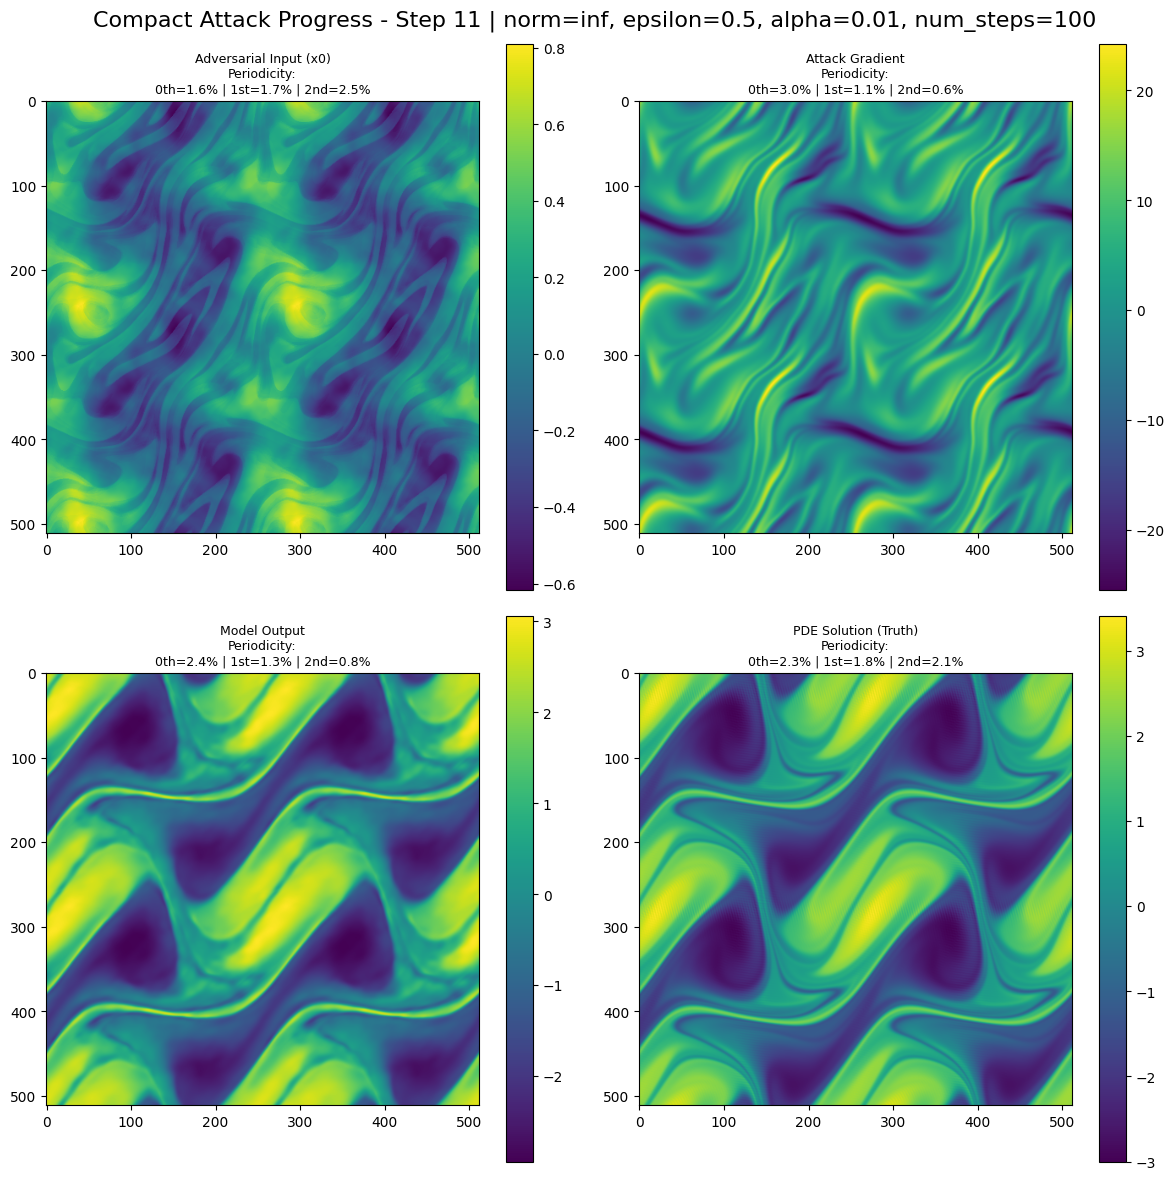

In [ ]:
import pickle
import os
from glob import glob

def process_pickle_files():
    # Get all pickle files in current directory
    pickle_files = glob("*.pkl")[:3]
    
    if not pickle_files:
        print("No .pkl files found in current directory")
        return
    
    for filename in pickle_files:
        try:
            print(f"Processing {filename}...")
            
            with open(filename, 'rb') as f:
                data = pickle.load(f)
            
            # Generate metadata string for filename
            metadata_str = "_".join([f"{key}{val}" for key, val in data["metadata"].items()])
            
            # Generate output filename (use original filename as base if metadata is empty)
            output_filename = f"attack_progress_{metadata_str}_periodic.gif" if metadata_str else f"attack_progress_{os.path.splitext(filename)[0]}.gif"
            
            # create_attack_visualization(
            create_compact_attack_visualization(
                data["steps"],
                output_path=output_filename,
                fps=5,
                metadata=data["metadata"]
            )
            
            print(f"Created visualization: {output_filename}")
            
        except Exception as e:
            print(f"Error processing {filename}: {str(e)}")

if __name__ == "__main__":
    process_pickle_files()